In [20]:
import os
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


định nghĩa đường dẫn đến dự án

In [16]:
import os

PROJECT_PATH = "/content/drive/MyDrive/cat_dog_project"

# Các đường dẫn con
DATA_PATH = os.path.join(PROJECT_PATH, "data")
TRAIN_PATH = os.path.join(DATA_PATH, "train")
VAL_PATH = os.path.join(DATA_PATH, "val")
TEST_PATH = os.path.join(DATA_PATH, "test")
MODEL_SAVE_PATH = os.path.join(PROJECT_PATH, "saved_models")

# Tạo thư mục saved_models
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

# Kiểm tra dữ liệu
print(f"Project path: {PROJECT_PATH}")
print(f"Train path: {TRAIN_PATH} - {'Exists' if os.path.exists(TRAIN_PATH) else 'Not found'}")
print(f"Val path: {VAL_PATH} - {'Exists' if os.path.exists(VAL_PATH) else 'Not found'}")
print(f"Test path: {TEST_PATH} - {'Exists' if os.path.exists(TEST_PATH) else 'Not found'}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Project path: /content/drive/MyDrive/cat_dog_project
Train path: /content/drive/MyDrive/cat_dog_project/data/train - Not found
Val path: /content/drive/MyDrive/cat_dog_project/data/val - Not found
Test path: /content/drive/MyDrive/cat_dog_project/data/test - Not found
Model save path: /content/drive/MyDrive/cat_dog_project/saved_models


import thư viện

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import time
from tqdm.auto import tqdm
import numpy as np

model

In [ ]:
class ImageClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        # Khối Tích chập 1: Nhận ảnh màu 3 kênh (RGB), xuất ra 64 kênh (feature maps)
        self.conv_layer_1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2)
        )

        # Khối Tích chập 2: Từ 64 kênh lên 512 kênh
        self.conv_layer_2 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2)
        )

        # Khối Tích chập 3: Giữ nguyên 512 kênh
        self.conv_layer_3 = nn.Sequential(
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2)
        )

        # Bộ Phân loại cuối cùng (Classifier)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # CHÚ Ý: Con số 512*3*3 được tác giả tính toán cứng (hardcoded)
            nn.Linear(in_features=512*3*3, out_features=2)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_layer_1(x)
        x = self.conv_layer_2(x)

        # Tác giả cố tình gọi khối conv_layer_3 lặp lại 4 lần
        # (Đây là một kỹ thuật để làm mạng sâu hơn mà không phải viết lại code)
        x = self.conv_layer_3(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_3(x)
        x = self.conv_layer_3(x)

        x = self.classifier(x)
        return x



train


In [ ]:
def train_step(model: nn.Module,
               dataloader: DataLoader,
               loss_fn: nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):

    model.train()
    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def val_step(model: nn.Module,
             dataloader: DataLoader,
             loss_fn: nn.Module,
             device: torch.device):

    model.eval()
    val_loss = 0
    val_acc = 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)

            val_pred_logits = model(X)
            loss = loss_fn(val_pred_logits, y)
            val_loss += loss.item()

            val_pred_labels = val_pred_logits.argmax(dim=1)
            val_acc += ((val_pred_labels == y).sum().item() / len(val_pred_labels))

    val_loss = val_loss / len(dataloader)
    val_acc = val_acc / len(dataloader)
    return val_loss, val_acc


def train(model: nn.Module,
          train_dataloader: DataLoader,
          val_dataloader: DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: nn.Module,
          epochs: int,
          device: torch.device):

    results = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)

        val_loss, val_acc = val_step(model=model,
                                     dataloader=val_dataloader,
                                     loss_fn=loss_fn,
                                     device=device)

        print(f"Epoch: {epoch+1} | "
              f"train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | "
              f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["val_loss"].append(val_loss)
        results["val_acc"].append(val_acc)

    return results

biểu đồ

In [ ]:
def plot_loss_curves(results):
    loss = results['train_loss']
    val_loss = results['val_loss']
    accuracy = results['train_acc']
    val_accuracy = results['val_acc']

    epochs = range(len(results['train_loss']))

    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label='train_loss')
    plt.plot(epochs, val_loss, label='val_loss')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label='train_accuracy')
    plt.plot(epochs, val_accuracy, label='val_accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend()

    plt.show()

cấu hình và load data

In [ ]:
# Cấu hình
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Đang sử dụng thiết bị: {device}")

BATCH_SIZE = 32
NUM_EPOCHS = 10
IMAGE_SIZE = (224, 224)

# Data transformations
data_transform = transforms.Compose([
    transforms.Resize(size=IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

# Load datasets
train_data = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_data = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)

print(f"Train samples: {len(train_data)}")
print(f"Val samples: {len(val_data)}")
print(f"Classes: {train_data.classes}")

num_workers = 0 if os.name == 'nt' else os.cpu_count()

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)

print("DataLoaders ready!")

Đang sử dụng thiết bị: cuda
Train samples: 8005
Val samples: 2023
Classes: ['cat', 'dog']
DataLoaders ready!


khởi tạo model và bắt đầu training


Bắt đầu huấn luyện mô hình
Batch size: 32, Epochs: 10


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8812 | train_acc: 0.6187 | val_loss: 0.7569 | val_acc: 0.6323
Epoch: 2 | train_loss: 0.7621 | train_acc: 0.6747 | val_loss: 0.9284 | val_acc: 0.6731
Epoch: 3 | train_loss: 0.6804 | train_acc: 0.7075 | val_loss: 0.5976 | val_acc: 0.7423
Epoch: 4 | train_loss: 0.5932 | train_acc: 0.7456 | val_loss: 0.5324 | val_acc: 0.7565
Epoch: 5 | train_loss: 0.5164 | train_acc: 0.7892 | val_loss: 0.5852 | val_acc: 0.7308
Epoch: 6 | train_loss: 0.4232 | train_acc: 0.8181 | val_loss: 0.4988 | val_acc: 0.8000
Epoch: 7 | train_loss: 0.3764 | train_acc: 0.8498 | val_loss: 0.3518 | val_acc: 0.8476
Epoch: 8 | train_loss: 0.3214 | train_acc: 0.8736 | val_loss: 0.3295 | val_acc: 0.8669
Epoch: 9 | train_loss: 0.2566 | train_acc: 0.9007 | val_loss: 0.4730 | val_acc: 0.8320
Epoch: 10 | train_loss: 0.1968 | train_acc: 0.9204 | val_loss: 0.4919 | val_acc: 0.8036
Tổng thời gian huấn luyện: 1536.994 giây


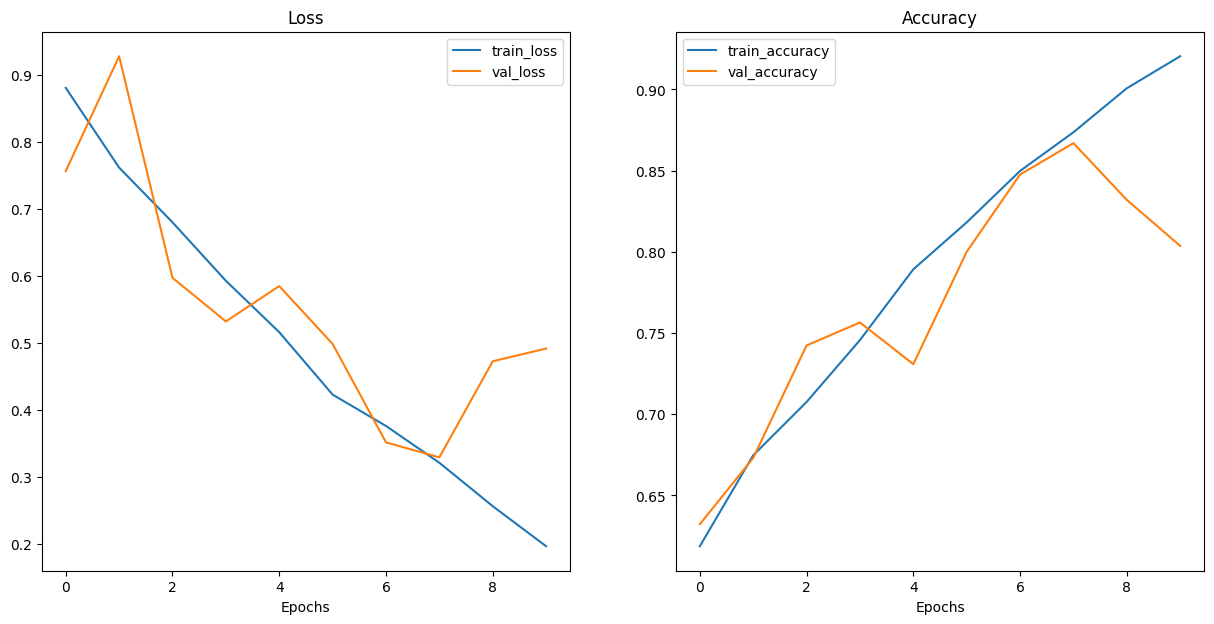

In [ ]:
model = ImageClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)

print("Bắt đầu huấn luyện mô hình")
print(f"Batch size: {BATCH_SIZE}, Epochs: {NUM_EPOCHS}")
start_time = time.time()

model_results = train(model=model,
                      train_dataloader=train_dataloader,
                      val_dataloader=val_dataloader,
                      optimizer=optimizer,
                      loss_fn=loss_fn,
                      epochs=NUM_EPOCHS,
                      device=device)

end_time = time.time()
print(f"Tổng thời gian huấn luyện: {(end_time - start_time):.3f} giây")

# Vẽ biểu đồ
plot_loss_curves(model_results)

lưu model đã train


In [ ]:
# Lưu model sau khi train xong (epoch cuối cùng)
save_path = os.path.join(MODEL_SAVE_PATH, "cat_dog_model.pth")
torch.save(model.state_dict(), save_path)
print(f"Đã lưu mô hình tại: {save_path}")

Đã lưu mô hình tại: /content/drive/MyDrive/cat_dog_project/saved_models/cat_dog_model.pth


thư viện để test

Chưa tìm thấy file mô hình


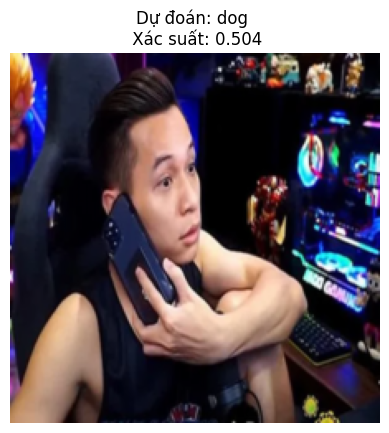

In [19]:
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt


"""Hàm đọc một bức ảnh bất kỳ, biến đổi và đưa qua mô hình dự đoán."""
def predict_custom_image(model, image_path, class_names, device="cpu"):
    custom_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Chuẩn hóa pixel về khoảng [0, 1]
    custom_image = custom_image / 255.0

    # 3. Tạo Pipeline biến đổi (Resize ảnh về kích thước chuẩn của Model)
    IMAGE_SIZE = (224, 224)
    custom_image_transform = transforms.Compose([
        transforms.Resize(IMAGE_SIZE),
    ])

    # 4. Áp dụng Transform
    custom_image_transformed = custom_image_transform(custom_image)

    # 5. Đưa mô hình về chế độ đánh giá
    model.eval()

    with torch.inference_mode():
        # Thêm chiều batch (batch dimension) bằng unsqueeze vì mô hình cần input [Batch, C, H, W]
        # Chuyển dữ liệu lên thiết bị (CPU/GPU)
        custom_image_input = custom_image_transformed.unsqueeze(dim=0).to(device)
        # Dự đoán logits
        custom_image_pred = model(custom_image_input)
        # Chuyển logits thành xác suất (probabilities)
        custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
        # Lấy nhãn có xác suất cao nhất
        custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1).item()

    # 6. Hiển thị kết quả bằng matplotlib
    plt.imshow(custom_image_transformed.permute(1, 2, 0))
    plt.title(f"Dự đoán: {class_names[custom_image_pred_label]} \n Xác suất: {custom_image_pred_probs[0][custom_image_pred_label]:.3f}")
    plt.axis("off")
    plt.show()


if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"
    class_names = ['cat', 'dog']

    model = ImageClassifier().to(device)

    model_load_path = os.path.join(MODEL_SAVE_PATH,"cat_dog_model_final.pth")

    try:
        model.load_state_dict(torch.load(model_load_path, map_location=device))
    except FileNotFoundError:
        print(f"Chưa tìm thấy file mô hình")

    # 3. Chọn một bức ảnh bất kỳ từ folder test để thử nghiệm
    test_image_path = os.path.join(TEST_PATH, "dog", "domixi.webp")

    if os.path.exists(test_image_path):
        predict_custom_image(model=model,
                             image_path=test_image_path,
                             class_names=class_names,
                             device=device)
    else:
        print(f"Không tìm thấy ảnh tại: {test_image_path}")